# Classification: Jammed or Unjammed?

## Introduction

In this notebook, we will classify each realization according to whether or not it is jammed. In the unjammed cases, we will study the polarization and size of the elongated clusters.

We start importing relevant libraries:

In [1]:
# Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import glob

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from matplotlib.lines import Line2D

And define parameters:

In [2]:
cell_area = np.pi
max_step = 80_000
step = 100
delta_t = 0.05

# All the seeds
number_of_realizations=64

seed_1 = 0x87351080E25CB0FAD77A44A3BE03B491
rng_1 = np.random.default_rng(seed_1)

rng_seed = rng_1.integers(
            low=2**20, high=2**50, size=number_of_realizations
        )

## Creating and saving dataset

Create a function to calculate the final clusters statistics.

In [3]:
def calculate_final_clusters(num_cells, max_step, dens, step, rng_seed, final_fraction=0.0):
    """
    Calculates cluster statistics at the final stage of the simulation.
    Returns overall means and raw temporal averages for each individual seed.

    Parameters
    ----------
    num_cells : int
        Number of cells in the simulation.
    max_step : int
        Final time step to analyze.
    dens : float
        Cell density used in the simulation.
    step : int
        Time step interval between saved data files.
    rng_seed : list of int
        List of random seeds corresponding to different simulation runs.
    final_fraction : float, optional
        Fraction of final time steps to average over (e.g., 0.1 for last 10%).

    Returns
    -------
    dict
        Dictionary containing means, std devs, and 'seeds_data' for per-seed analysis.
    """
    dens_folder = f"{dens:.3f}".replace(".", "_")
    num_cells_folder = f"N={num_cells:_}"

    # Determine the last valid step available across all seeds
    stop = False
    for tic in range(100, max_step + step, step):
        for seed in rng_seed:
            dat_actual = (
                f"data/{num_cells_folder}/{dens_folder}/dat_clusters/max_number/"
                f"clusters_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_With_Shrinking_"
                f"rng_seed={seed}_step={tic:05}.dat"
            )
            if not os.path.exists(dat_actual):
                stop = True
                break
        if stop:
            last_step = tic - step
            break
    else:
        last_step = max_step

    print(f"Last step found: {last_step} for density: {dens}")

    # Define the window of time steps to average
    all_steps = list(range(100, last_step + step, step))
    if final_fraction > 0:
        n_final = max(1, int(len(all_steps) * final_fraction))
        steps_to_use = all_steps[-n_final:]
    else:
        steps_to_use = [last_step]

    # Initialize lists to store temporal averages per seed
    # Label 1 lists
    s_max_round, s_2max_round, n_round, s_ratio_round = [], [], [], []
    s_max_elong, s_2max_elong, n_elong, s_ratio_elong = [], [], [], []
    
    # Label 2 lists
    s_max_round_2, s_2max_round_2, n_round_2, s_ratio_round_2 = [], [], [], []
    s_max_elong_2, s_2max_elong_2, n_elong_2, s_ratio_elong_2 = [], [], [], []

    for seed in rng_seed:
        dfs = []
        for s in steps_to_use:
            dat_path = (
                f"data/{num_cells_folder}/{dens_folder}/dat_clusters/max_number/"
                f"clusters_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_With_Shrinking_"
                f"rng_seed={seed}_step={s:05}.dat"
            )
            if os.path.exists(dat_path):
                dfs.append(pd.read_csv(dat_path))

        if not dfs:
            continue

        df_seed = pd.concat(dfs, ignore_index=True)
        
        # Temporal averaging for Label 1
        s_max_round.append(df_seed["max_round"].mean())
        s_2max_round.append(df_seed["2_max_round"].mean())
        n_round.append(df_seed["n_round"].mean())
        s_ratio_round.append((df_seed["2_max_round"] / df_seed["max_round"].replace(0, np.nan)).mean())
        
        s_max_elong.append(df_seed["max_elongated"].mean())
        s_2max_elong.append(df_seed["2_max_elongated"].mean())
        n_elong.append(df_seed["n_elongated"].mean())
        s_ratio_elong.append((df_seed["2_max_elongated"] / df_seed["max_elongated"].replace(0, np.nan)).mean())

        # Temporal averaging for Label 2
        s_max_round_2.append(df_seed["max_round_2"].mean())
        s_2max_round_2.append(df_seed["2_max_round_2"].mean())
        n_round_2.append(df_seed["n_round_2"].mean())
        s_ratio_round_2.append((df_seed["2_max_round_2"] / df_seed["max_round_2"].replace(0, np.nan)).mean())
        
        s_max_elong_2.append(df_seed["max_elongated_2"].mean())
        s_2max_elong_2.append(df_seed["2_max_elongated_2"].mean())
        n_elong_2.append(df_seed["n_elongated_2"].mean())
        s_ratio_elong_2.append((df_seed["2_max_elongated_2"] / df_seed["max_elongated_2"].replace(0, np.nan)).mean())

    return {
        "mean": {
            # Label 1 Means
            "MAX_round": np.mean(s_max_round), 
            "2_MAX_round": np.mean(s_2max_round), 
            "N_round": np.mean(n_round),
            "MAX_elongated": np.mean(s_max_elong), 
            "2_MAX_elongated": np.mean(s_2max_elong),
            "N_elongated": np.mean(n_elong),
            "ratio_s_round": np.mean(s_ratio_round),
            
            # Label 2 Means (Added for deeper Unjammed analysis)
            "MAX_round_2": np.mean(s_max_round_2),
            "2_MAX_round_2": np.mean(s_2max_round_2),
            "N_round_2": np.mean(n_round_2),
            "MAX_elongated_2": np.mean(s_max_elong_2),
            "2_MAX_elongated_2": np.mean(s_2max_elong_2),
            "N_elongated_2": np.mean(n_elong_2),
            "ratio_s_round_2": np.mean(s_ratio_round_2),
            "ratio_s_elongated_2": np.mean(s_ratio_elong_2)
        },
        "seeds_data": {
            "s_max_round": s_max_round, 
            "s_max_round_2": s_max_round_2,
            "s_max_elong_2": s_max_elong_2,
            "s_2max_elong_2": s_2max_elong_2,
            "n_round": n_round, 
            "n_round_2": n_round_2,
            "n_elong_2": n_elong_2,
            "ratio_round": s_ratio_round, 
            "ratio_round_2": s_ratio_round_2
        },
        "last_step": last_step
    }

And another function to calculate the final phenotype statistics:

In [4]:
def calculate_final_phenotype(num_cells, max_step, dens, step, rng_seed, final_fraction=0.0):
    """
    Calculates phenotype statistics averaging over the final fraction of steps.
    Returns per-seed temporal averages.

    Parameters
    ----------
    num_cells : int
        Number of cells in the simulation.
    max_step : int
        Final time step to analyze.
    dens : float
        Cell density used in the simulation.
    step : int
        Time step interval between saved data files.
    rng_seed : list of int
        List of random seeds for ensemble averaging.
    final_fraction : float, optional
        Fraction of the total trajectory to average (e.g., 0.1).

    Returns
    -------
    dict
        Dictionary with ensemble means and 'seeds_data' for individual realization analysis.
    """
    dens_folder = f"{dens:.3f}".replace(".", "_")
    num_cells_folder = f"N={num_cells:_}"
    
    stop = False
    for tic in range(100, max_step + step, step):
        for seed in rng_seed:
            dat_actual = (
                f"data/{num_cells_folder}/{dens_folder}/dat_phenotype/"
                f"phenotype_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_"
                f"With_Shrinking_rng_seed={seed}_step={tic:05}.dat"
            )
            if not os.path.exists(dat_actual):
                stop = True
                break
        if stop:
            last_step = tic - step
            break
    else:
        last_step = max_step
    
    print(f"Last step found: {last_step} for density: {dens}")
    
    all_steps = list(range(100, last_step + step, step))
    if final_fraction > 0:
        n_final = max(1, int(len(all_steps) * final_fraction))
        steps_to_use = all_steps[-n_final:]
    else:
        steps_to_use = [last_step]

    # Initialize lists for per-seed results
    seeds_f_elongated, seeds_f_round, seeds_f_binary, seeds_aspect_ratio = [], [], [], []

    for seed in rng_seed:
        dfs = []
        for s in steps_to_use:
            dat_path = (
                f"data/{num_cells_folder}/{dens_folder}/dat_phenotype/"
                f"phenotype_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_"
                f"With_Shrinking_rng_seed={seed}_step={s:05}.dat"
            )
            if os.path.exists(dat_path):
                dfs.append(pd.read_csv(dat_path))
        
        if not dfs:
            continue
        
        df_seed = pd.concat(dfs, ignore_index=True)
        
        # Temporal means for this specific seed
        seeds_f_elongated.append(df_seed["fraction_elongated"].mean())
        seeds_f_round.append(df_seed["fraction_round"].mean())
        seeds_f_binary.append(df_seed["fraction_binary"].mean())
        seeds_aspect_ratio.append(df_seed["mean_aspect_ratio"].mean())

    return {
        "mean": {
            "mean_aspect_ratio": np.mean(seeds_aspect_ratio),
            "fraction_elongated": np.mean(seeds_f_elongated),
            "fraction_round": np.mean(seeds_f_round),
            "fraction_binary": np.mean(seeds_f_binary),
        },
        "seeds_data": {
            "f_elongated": seeds_f_elongated,
            "f_round": seeds_f_round,
            "f_binary": seeds_f_binary,
            "aspect_ratio": seeds_aspect_ratio
        }
    }

And now we use these functions to collect the data:

In [5]:
# Choose the number of cells and densities
Ns = [1000, 2000, 3000, 5000, 10000]

densities_dict = {

    10000: [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.855, 0.858,
            0.86, 0.862, 0.865, 0.87, 0.88, 0.9],

    5000:  [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.845, 0.85,
            0.855, 0.86, 0.87, 0.88, 0.9],

    3000:  [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.85,
            0.86, 0.87, 0.88, 0.9],

    2000:  [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.845, 0.848,
            0.85, 0.852, 0.855, 0.86, 0.87, 0.88, 0.9],

    1000:  [0.4, 0.5, 0.6, 0.7, 0.75, 0.76, 0.77, 0.78, 0.79,
            0.8, 0.81, 0.82, 0.83, 0.84, 0.845, 0.848,
            0.85, 0.852, 0.855, 0.86, 0.87, 0.88, 0.9],
}

# Create lists to store data
X_all = []
rho_labels = []
N_labels = []
seed_labels = []

# Read every N and rho
for N in Ns:
    for rho in densities_dict[N]:
        # Calculate the final clusters
        cluster_data = calculate_final_clusters(
            N, max_step, rho, step, rng_seed, final_fraction=0.1
        )
        # Calculate the final phenotypes
        pheno_data = calculate_final_phenotype(
            N, max_step, rho, step, rng_seed, final_fraction=0.1
        )
        # Take the data
        s_max_norm = np.array(cluster_data["seeds_data"]["s_max_round"]) / N
        s_max_norm_2 = np.array(cluster_data["seeds_data"]["s_max_round_2"]) / N
        f_elongated = np.array(pheno_data["seeds_data"]["f_elongated"])
        f_binary = np.array(pheno_data["seeds_data"]["f_binary"])
        # Add them to the lists
        for fe, fb, s, s_2, seed in zip(f_elongated, f_binary, s_max_norm, s_max_norm_2, rng_seed):
            fa = fe + fb
            X_all.append([fe, fb, fa, s, s_2])
            rho_labels.append(rho)
            N_labels.append(N)
            seed_labels.append(seed)

X_all = np.array(X_all)
rho_labels = np.array(rho_labels)
N_labels = np.array(N_labels)
seed_labels = np.array(seed_labels)

# Take every important feature
f_elongated_all = X_all[:, 0]
f_binary_all = X_all[:, 1]
f_active_all = X_all[:, 2]
s_all = X_all[:, 3]
s_2_all = X_all[:, 4]

# Save everything in a csv
df = pd.DataFrame({
    "N": N_labels,
    "seed": seed_labels,
    "rho": rho_labels,
    "f_elongated": f_elongated_all,
    "f_binary": f_binary_all,
    "f_active": f_active_all,
    "s_max_norm": s_all,
    "s_max_norm_2": s_2_all
})

folder_path = "data/processed/jamming"
os.makedirs(folder_path, exist_ok=True)

df.to_csv(f"{folder_path}/final_dataset.csv", index=False)

Last step found: 70000 for density: 0.4
Last step found: 70000 for density: 0.4
Last step found: 70000 for density: 0.5
Last step found: 70000 for density: 0.5
Last step found: 70000 for density: 0.6
Last step found: 70000 for density: 0.6
Last step found: 70000 for density: 0.7
Last step found: 70000 for density: 0.7
Last step found: 70000 for density: 0.75
Last step found: 70000 for density: 0.75
Last step found: 70000 for density: 0.76
Last step found: 70000 for density: 0.76
Last step found: 70000 for density: 0.77
Last step found: 70000 for density: 0.77
Last step found: 70000 for density: 0.78
Last step found: 70000 for density: 0.78
Last step found: 70000 for density: 0.79
Last step found: 70000 for density: 0.79
Last step found: 70000 for density: 0.8
Last step found: 70000 for density: 0.8
Last step found: 70000 for density: 0.81
Last step found: 70000 for density: 0.81
Last step found: 70000 for density: 0.82
Last step found: 70000 for density: 0.82
Last step found: 70000 for

## Reading dataset

We read the dataset previously created

In [5]:
# Read
df = pd.read_csv("data/processed/jamming/final_dataset.csv")

# Take the useful features
N_labels = df["N"].values
seed_labels = df["seed"].values
rho_labels = df["rho"].values
f_elongated_all = df["f_elongated"].values
f_binary_all = df["f_binary"].values
f_active_all = df["f_active"].values
s_all = df["s_max_norm"].values
s_2_all = df["s_max_norm_2"].values

## Global phase space

Now we are going to plot different graphs to see if we can classificate if a realization is jammed or unjammed.

We can study the size of the largest cluster of round cells (for both labels 1 and 2) and the fraction of active cells.

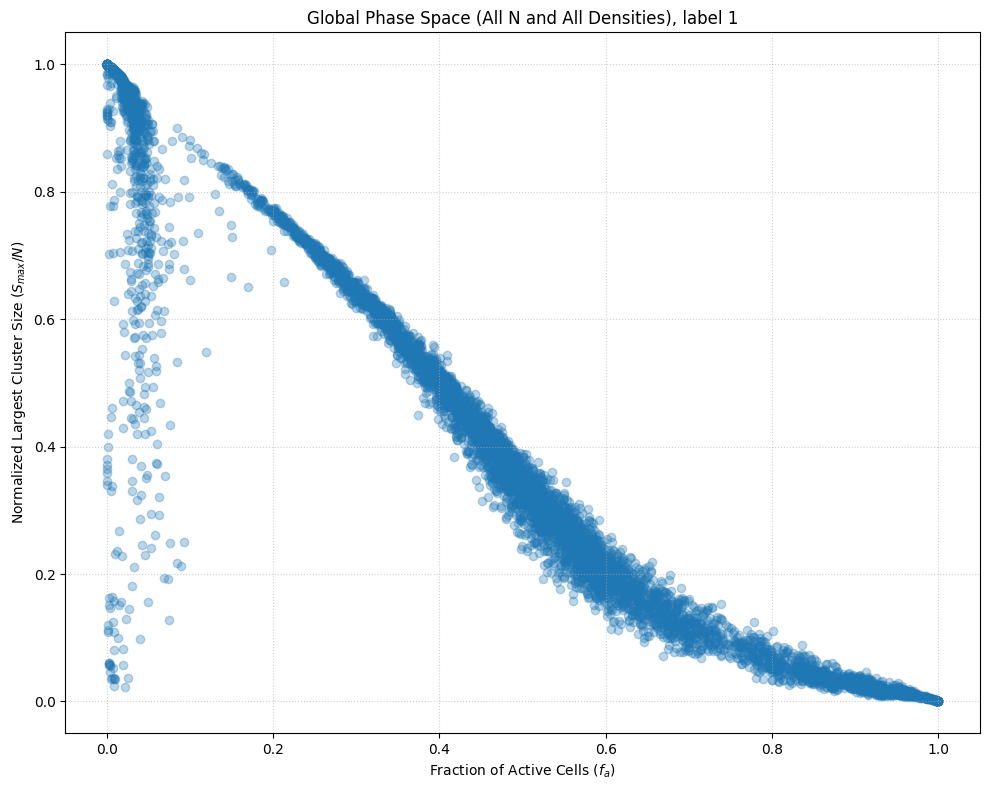

In [6]:
# Create the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(f_active_all, s_all, alpha=0.3)

# Configuration
ax.set_xlabel("Fraction of Active Cells ($f_a$)")
ax.set_ylabel("Normalized Largest Cluster Size ($S_{max}/N$)")
ax.set_title("Global Phase Space (All N and All Densities), label 1")
ax.grid(True, linestyle=":", alpha=0.6)

# Save the figure
folder_path = "graphs/jamming/global_plots"
os.makedirs(folder_path, exist_ok=True)
plt.tight_layout()
plt.savefig(f"{folder_path}/global_phase_space_label_1.png", dpi=600)

plt.show()

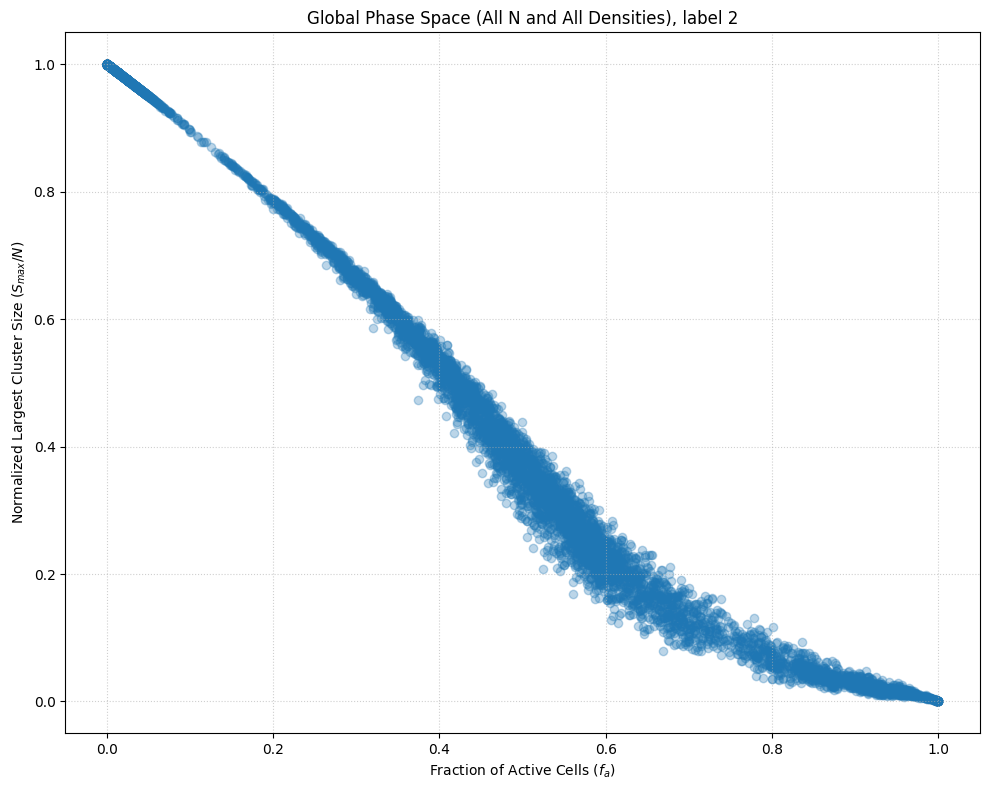

In [7]:
# Create the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(f_active_all, s_2_all, alpha=0.3)

# Configuration
ax.set_xlabel("Fraction of Active Cells ($f_a$)")
ax.set_ylabel("Normalized Largest Cluster Size ($S_{max}/N$)")
ax.set_title("Global Phase Space (All N and All Densities), label 2")
ax.grid(True, linestyle=":", alpha=0.6)

# Save the figure
folder_path = "graphs/jamming/global_plots"
os.makedirs(folder_path, exist_ok=True)
plt.tight_layout()
plt.savefig(f"{folder_path}/global_phase_space_label_2.png", dpi=600)

plt.show()

Here we can see that for label 1 there are a lot of points that lie in the zone wit $f_a \approx 0$ and a lot of different values of $s$. This is not what we expected because when $f_a \approx 0$, all the cells are round and we should see $s \approx 1$. Because of this, we can use label 2.

## DBSCAN

We are going to apply DBSCAN in order to see if we can differentiate 2 clusters.

eps = 0.030
Clusters encontrados: 6
Puntos marcados como ruido: 564


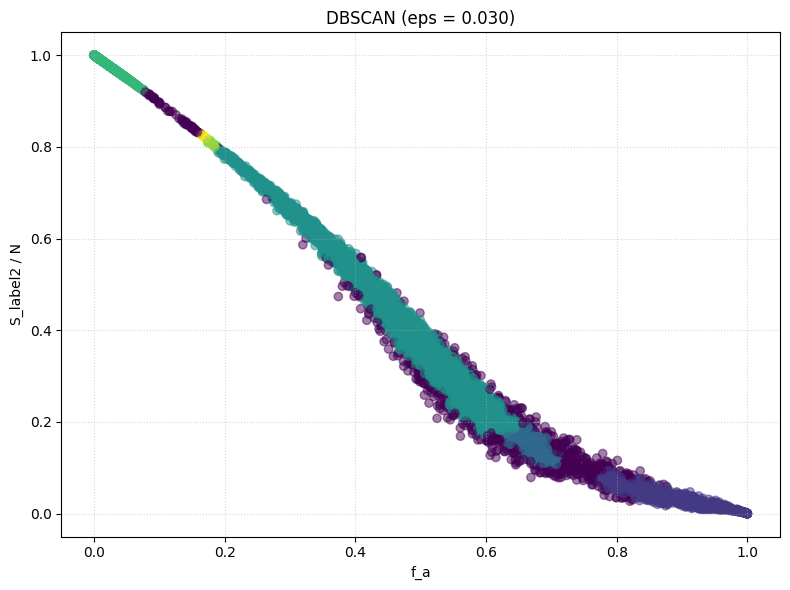

eps = 0.040
Clusters encontrados: 2
Puntos marcados como ruido: 119


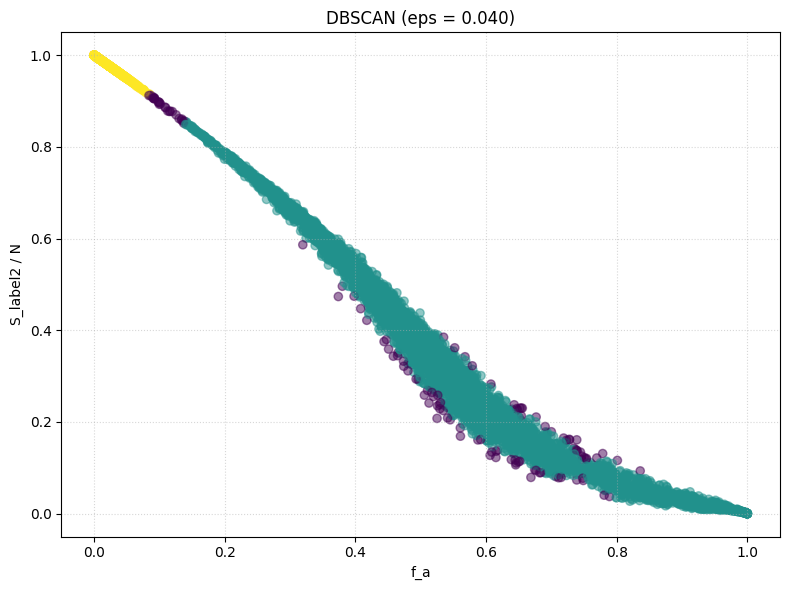

eps = 0.050
Clusters encontrados: 2
Puntos marcados como ruido: 31


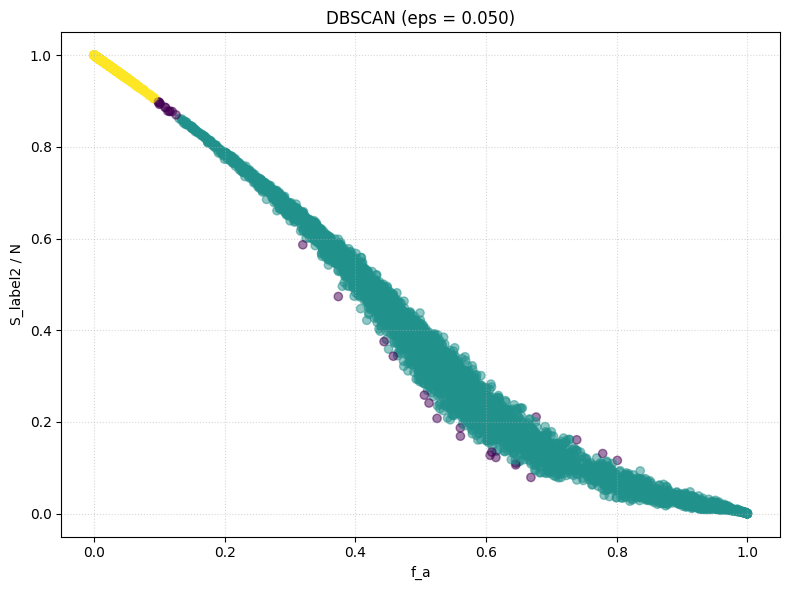

eps = 0.060
Clusters encontrados: 2
Puntos marcados como ruido: 13


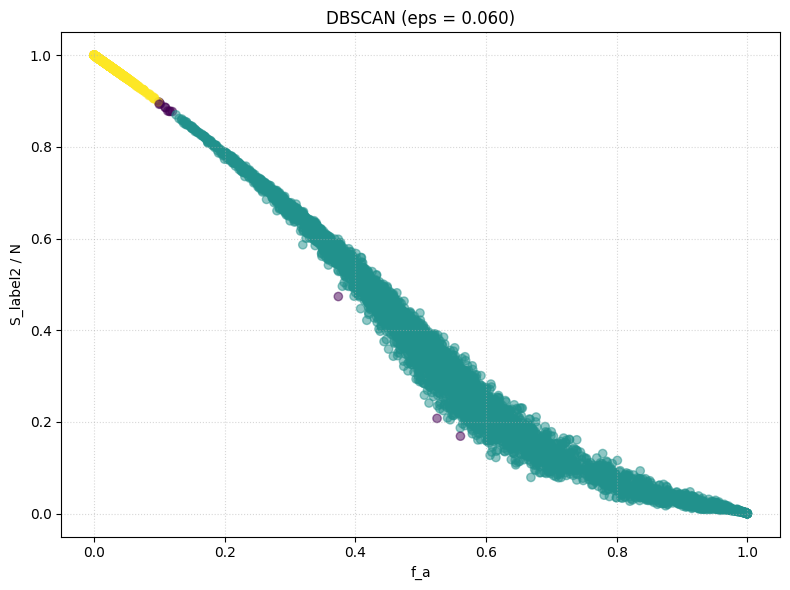

eps = 0.070
Clusters encontrados: 2
Puntos marcados como ruido: 7


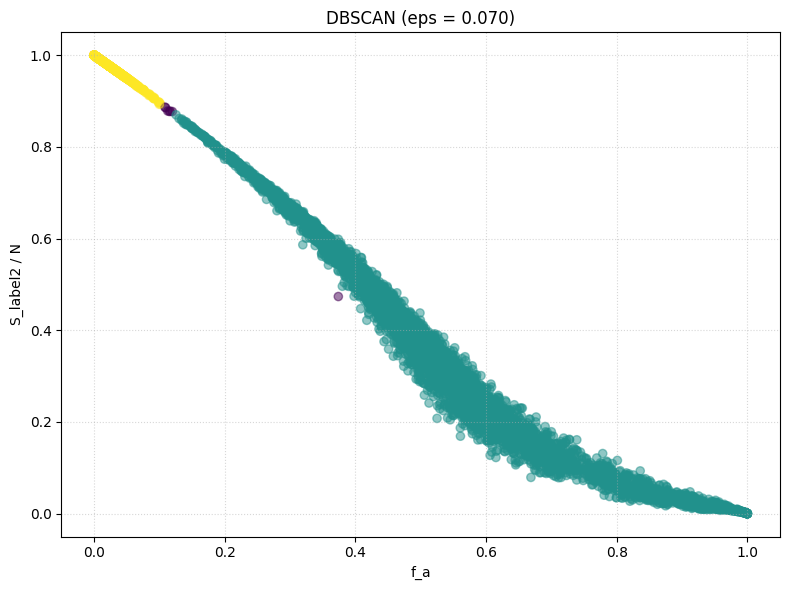

eps = 0.080
Clusters encontrados: 2
Puntos marcados como ruido: 0


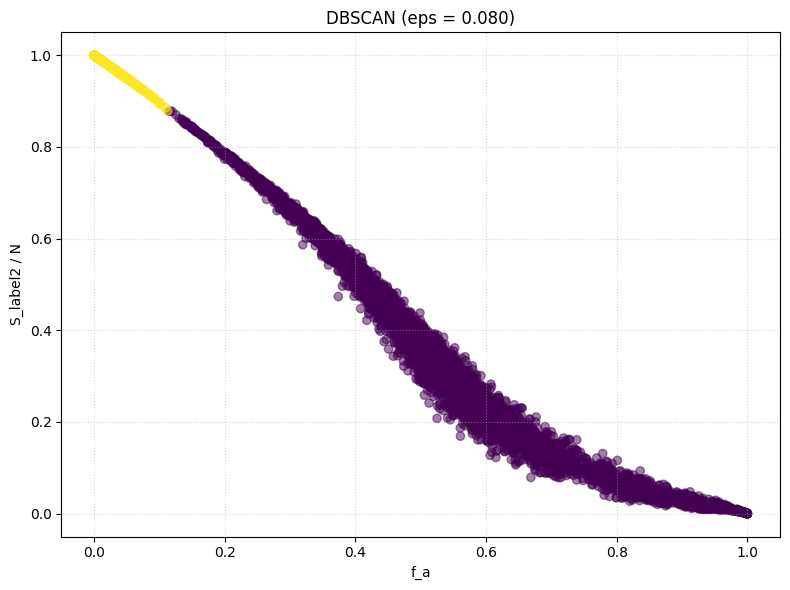

eps = 0.090
Clusters encontrados: 2
Puntos marcados como ruido: 0


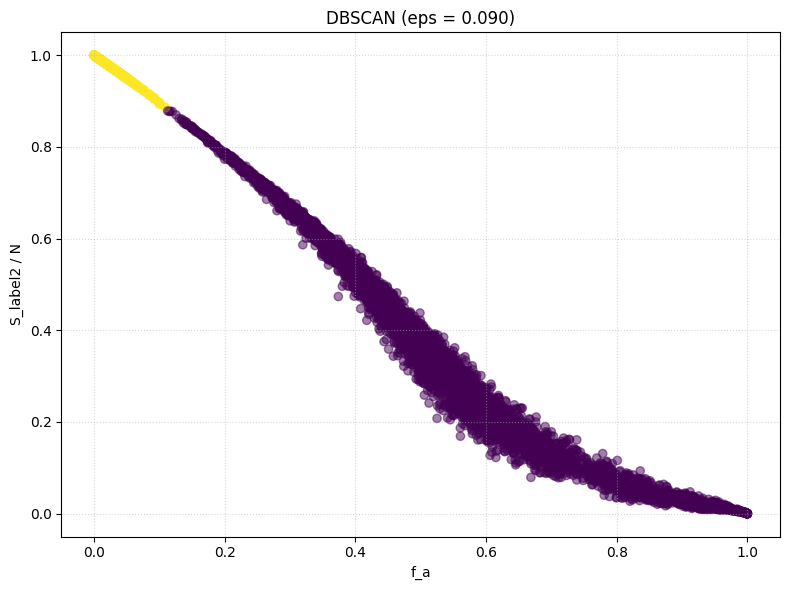

eps = 0.100
Clusters encontrados: 2
Puntos marcados como ruido: 0


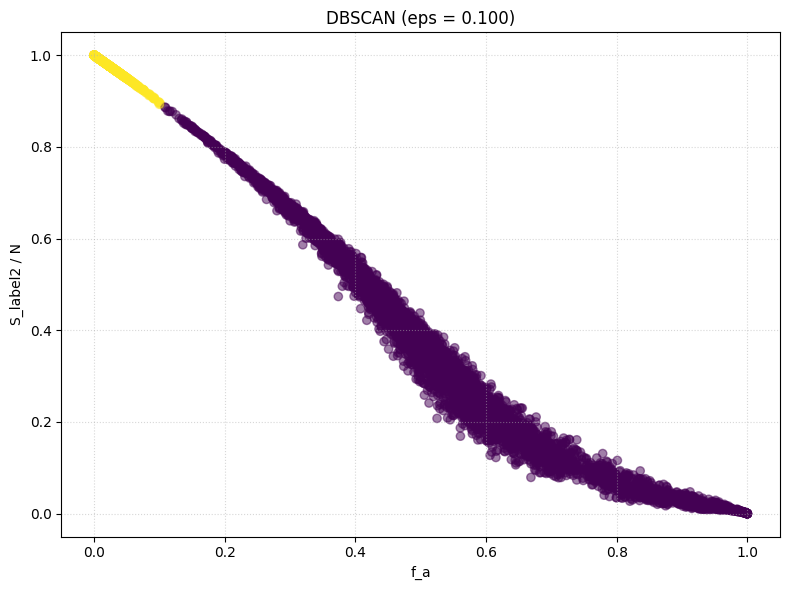

eps = 0.200
Clusters encontrados: 1
Puntos marcados como ruido: 0


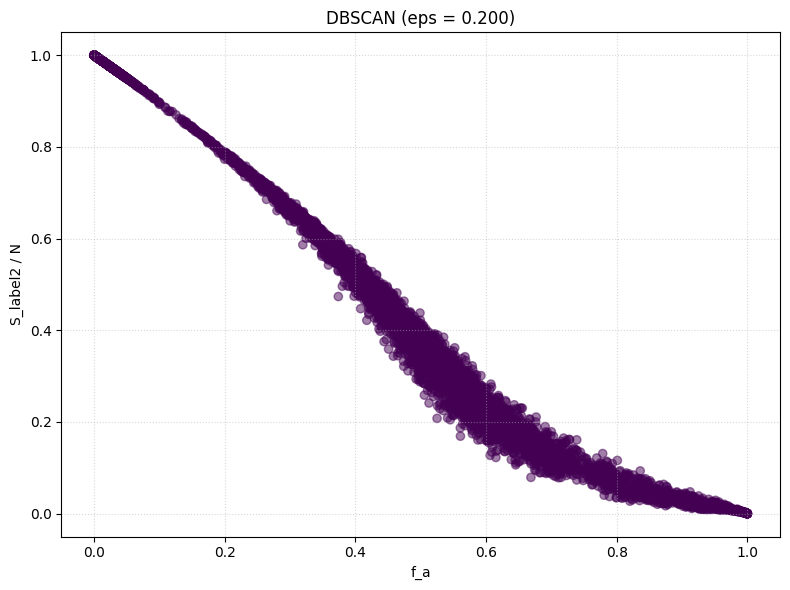

eps = 0.500
Clusters encontrados: 1
Puntos marcados como ruido: 0


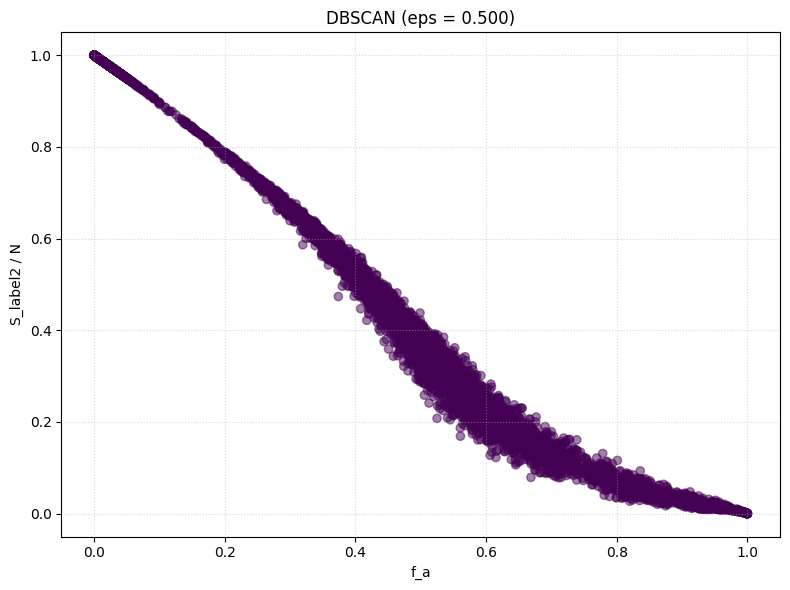

eps = 1.000
Clusters encontrados: 1
Puntos marcados como ruido: 0


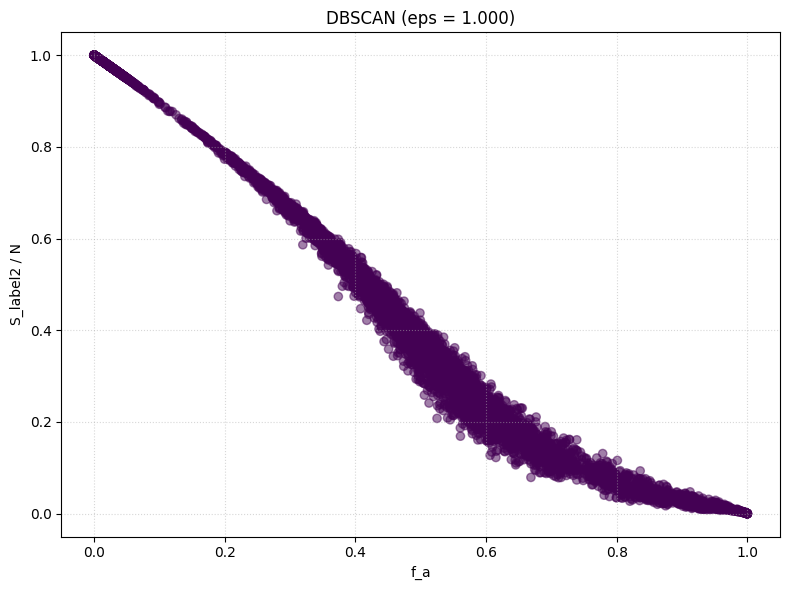

In [8]:
# Use f_a and s_label2
X = np.column_stack((f_active_all, s_2_all))

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create folder to save the figures
folder_path = "graphs/jamming/dbscan_sweep"
os.makedirs(folder_path, exist_ok=True)

# Values of epsilon
eps_values = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.5, 1.0]

# Bucle for eps
for eps in eps_values:
    
    # Define DBSCAN, fit and predict
    db = DBSCAN(eps=eps, min_samples=20)
    labels = db.fit_predict(X_scaled)

    # Take the number of clusters and noise
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps = {eps:.3f}")
    print("Clusters encontrados:", n_clusters)
    print("Puntos marcados como ruido:", n_noise)

    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", alpha=0.5)

    plt.xlabel("f_a")
    plt.ylabel("S_label2 / N")
    plt.title(f"DBSCAN (eps = {eps:.3f})")
    plt.grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"{folder_path}/DBSCAN_eps_{eps:.3f}.png", dpi=600)
    plt.show()
    plt.close()

As we can see, it is easy to see that DBSCAN separate the data into 2 clusters. We can use $\epsilon=0.08$ that is the first time where there is no points classified as noise. To complete this idea, we can study the distribution of active cells.

## Distribution of fraction of active cells

We can also see the distribution of fraction of elongated cells.

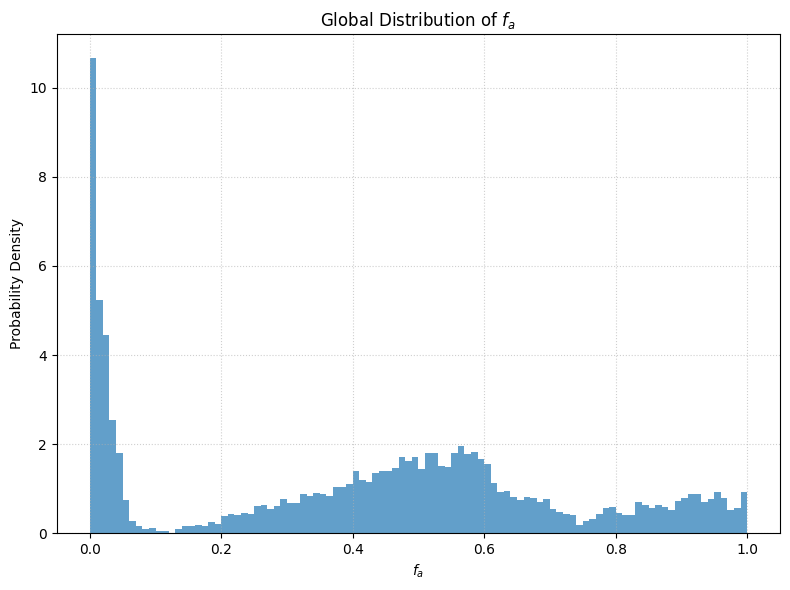

In [9]:
# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
counts, bins, _ = ax.hist(f_active_all, bins=100, density=True, alpha=0.7)

# Configuration
ax.set_xlabel("$f_a$")
ax.set_ylabel("Probability Density")
ax.set_title("Global Distribution of $f_a$")
ax.grid(True, linestyle=":", alpha=0.6)

# Save the figure
folder_path = "graphs/jamming/global_plots"
os.makedirs(folder_path, exist_ok=True)
plt.tight_layout()
plt.savefig(f"{folder_path}/global_distribution_f_a.png", dpi=600)

plt.show()

## Classification

To distinguish between Jammed and Unjammed realizations, we will use the results given by the DBSCAN analysis. After a sweep of the epsilon parameter, we choose $\epsilon = 0.08$. This value represents the first instance where the algorithm successfully resolves the system into two distinct clusters without noise, capturing the inherent bimodality of the transition.

To refine the classification, we see if this classification is inn agreement with a line given by $f_a = 0.12$, where we see a valley in the distribution.

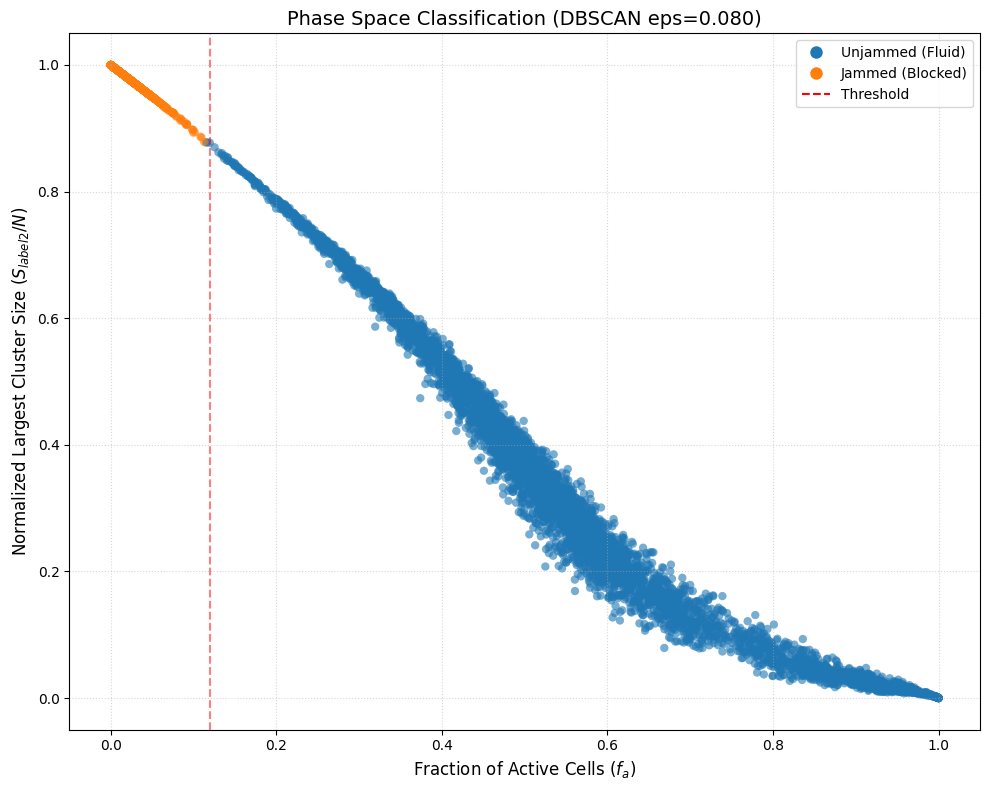

Summary of Classification:
Total points: 6976
Unjammed (Fluid): 5150
Jammed (Blocked): 1826


In [10]:
# Get the data
X = np.column_stack((f_active_all, s_2_all))

# Define the scaler and scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Execute final DBSCAN
final_eps = 0.08
min_samples = 20

db = DBSCAN(eps=final_eps, min_samples=min_samples)
# Define the initial labels given bby DBSCAN
initial_labels = db.fit_predict(X_scaled)

# Identify original clusters
unique_labels = set(initial_labels)
if -1 in unique_labels:
    unique_labels.remove(-1)

# Define unjammed as the one that has less value of s_r
cluster_means = {l: np.mean(X[initial_labels == l, 1]) for l in unique_labels}
unjammed_label = min(cluster_means, key=cluster_means.get)
jammed_label = max(cluster_means, key=cluster_means.get)

# Create a copy of the labels
final_labels = initial_labels.copy()

# Define labels
LABEL_UNJAMMED = 0
LABEL_JAMMED = 1

# Map clusters with the clusters
final_labels[initial_labels == unjammed_label] = LABEL_UNJAMMED
final_labels[initial_labels == jammed_label] = LABEL_JAMMED

# Threshold seen in teh distribution of active cells
threshold = 0.12

# Define colors for each phase
colors = {LABEL_UNJAMMED: '#1f77b4',
          LABEL_JAMMED: '#ff7f0e',}

color_labels = [colors[l] for l in final_labels]

# Plot
plt.figure(figsize=(10, 8))

# Scatter of the points
plt.scatter(X[:, 0], X[:, 1], c=color_labels, alpha=0.6, edgecolors='none')

# Plot the line of rescue
plt.axvline(threshold, color='r', linestyle='--', alpha=0.5, label=f'Threshold ({threshold})')

plt.xlabel("Fraction of Active Cells ($f_a$)", fontsize=12)
plt.ylabel("Normalized Largest Cluster Size ($S_{label2}/N$)", fontsize=12)
plt.title(f"Phase Space Classification (DBSCAN eps={final_eps:.3f})", fontsize=14)

# Legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Unjammed (Fluid)',
                          markerfacecolor=colors[LABEL_UNJAMMED], markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Jammed (Blocked)',
                          markerfacecolor=colors[LABEL_JAMMED], markersize=10),
                   Line2D([0], [0], color='r', linestyle='--', label='Threshold')]
plt.legend(handles=legend_elements, loc='best')

plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()

# Save the plot
graph_folder = "graphs/jamming/classification"
os.makedirs(graph_folder, exist_ok=True)
plt.savefig(f"{graph_folder}/Classified_Scatter_eps_{final_eps:.3f}.png", dpi=600)

plt.show()
plt.close()

# Summary
print("Summary of Classification:")
print(f"Total points: {len(final_labels)}")
print(f"Unjammed (Fluid): {np.sum(final_labels == LABEL_UNJAMMED)}")
print(f"Jammed (Blocked): {np.sum(final_labels == LABEL_JAMMED)}")

And now we create a dataframe with the classification for each realization.

In [11]:
# Add the labels and status
df["classification"] = final_labels
status_map = {
    LABEL_UNJAMMED: "unjammed",
    LABEL_JAMMED: "jammed"
}
df["status"] = df["classification"].map(status_map)

# Save the CSV
output_path = "data/processed/jamming/final_dataset_classified.csv"
df.to_csv(output_path, index=False)

## Separation

We are going to separate the ovito files depending on their status.

In [12]:
# Root path
data_root = "data"

# Remove existing classified folders
for (n_val, rho_val) in df[['N', 'rho']].drop_duplicates().values:
    
    n_folder = f"N={int(n_val):_}"
    rho_folder = f"{rho_val:.3f}".replace(".", "_")
    
    classified_dir = f"{data_root}/{n_folder}/{rho_folder}/ovito_classified"
    
    if os.path.exists(classified_dir):
        shutil.rmtree(classified_dir)

# Copy files into new classified folders
for index, row in df.iterrows():
    
    n_val = int(row['N'])
    rho_val = row['rho']
    seed_val = int(row['seed'])
    status = row['status']
    
    n_folder = f"N={n_val:_}"
    rho_folder = f"{rho_val:.3f}".replace(".", "_")
    
    # Path with wildcard for the final step
    source_dir = f"{data_root}/{n_folder}/{rho_folder}/ovito_final"
    
    search_pattern = os.path.join(
        source_dir,
        f"ovito_data_culture_initial_number_of_cells={n_val}_density={rho_val}_force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_With_Shrinking_rng_seed={seed_val}.*"
    )
    
    # glob returns a list of matching files
    matching_files = glob.glob(search_pattern)
    
    if matching_files:
        source_path = matching_files[0]
        filename = os.path.basename(source_path)
        
        # Destination directory
        dest_dir = f"{data_root}/{n_folder}/{rho_folder}/ovito_classified/{status}"
        os.makedirs(dest_dir, exist_ok=True)
        
        dest_path = os.path.join(dest_dir, filename)
        
        shutil.copy2(source_path, dest_path)
    
    else:
        print(f"Warning: File not found for Seed {seed_val} in {source_dir}")

## Jamming probability

Now, let's plot the probability of jamming, given the classification done before.

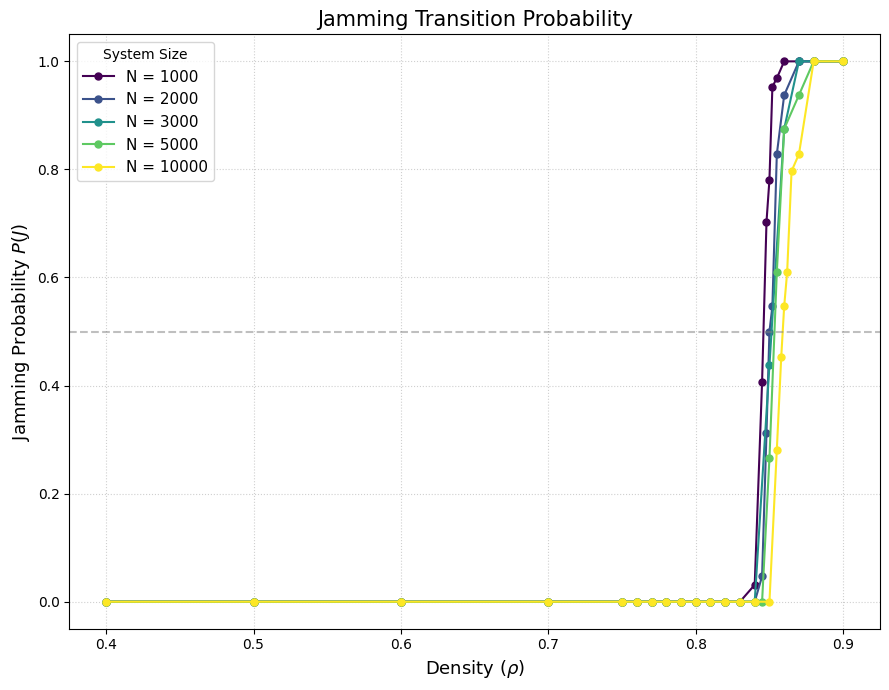

In [14]:
# Load classified dataset
df = pd.read_csv("data/processed/jamming/final_dataset_classified.csv")

# Calculate probability of jamming
# P(J) = (number of jammed) / (total number of realizations per point)
pj_data = df.groupby(['N', 'rho'])['classification'].mean().reset_index()
pj_data.rename(columns={'classification': 'P_J'}, inplace=True)

# Plot
plt.figure(figsize=(9, 7))

colors = plt.cm.viridis(np.linspace(0, 1, len(pj_data['N'].unique())))
Ns = sorted(pj_data['N'].unique())

for i, N in enumerate(Ns):
    subset = pj_data[pj_data['N'] == N]
    plt.plot(subset['rho'], subset['P_J'], 'o-', label=f'N = {N}', color=colors[i], markersize=5)

plt.xlabel(r"Density ($\rho$)", fontsize=13)
plt.ylabel(r"Jamming Probability $P(J)$", fontsize=13)
plt.title("Jamming Transition Probability", fontsize=15)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(title="System Size", fontsize=11)

# Guide line in 0.5
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save
graph_folder = "graphs/jamming/probability"
os.makedirs(graph_folder, exist_ok=True)
plt.savefig(f"{graph_folder}/probability_jamming_vs_rho.png", dpi=600)
plt.show()

## Analyzing unjammed phase

Finally, let's analized the unjammed phase.

### Creation of dataframe

We start creating a function to calculate the order parameters at the final stage of the simulations.

In [6]:
def calculate_final_order_parameter(num_cells, max_step, dens, step, rng_seed, final_fraction=0.0):
    """
    Calculates the order parameters at the final stage of the simulation for a given density,
    averaging over multiple seeds.

    If final_fraction > 0, averages over the last fraction of available time steps
    instead of only the final step.

    Parameters
    ----------
    num_cells : int
        Number of cells in the simulation.
    max_step : int
        Final time step to analyze.
    dens : float
        Cell density used in the simulation.
    step : int
        Time step interval between saved data files.
    rng_seed : list of int
        List of random seeds corresponding to different simulation runs.
    final_fraction : float, optional
        Fraction of final time steps to average over (e.g., 0.1 for last 10%).
        If 0.0 (default), only the last step is used.

    Returns
    -------
    dict
        Dictionary with the mean and standard deviation of the polar and 
        nematic order parameters at the final time step.
    """
    # Name of the density folder to read the data
    dens_folder = f"{dens:.3f}".replace(".", "_")
    num_cells_folder = f"N={num_cells:_}"
    # Define a boolean to stop where there are no more data
    stop = False
    # Check for which was the last step
    for tic in range(100, max_step, step):
        for seed in rng_seed:
            dat_actual = f"data/{num_cells_folder}/{dens_folder}/dat_order_parameters/op_culture_initial_number_of_cells={num_cells}_density={dens}_force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_With_Shrinking_rng_seed={seed}_step={tic:05}.dat"
            if not os.path.exists(dat_actual):
                stop = True
                break
        if stop is True:
            last_step = tic - step
            break
    else:
        # if the for does not break, last step is the max
        last_step = max_step
    
    print("Last step = ", last_step, " for density = ", dens)
    
    # Build list of steps to use
    all_steps = list(range(100, last_step + step, step))

    if final_fraction > 0:
        n_final = max(1, int(len(all_steps) * final_fraction))
        steps_to_use = all_steps[-n_final:]
    else:
        steps_to_use = [last_step]

    # Initialize the lists for order parameters 1
    nematic_order = []
    polar_order = []
    # and for op 2
    nematic_2_order = []
    polar_2_order = []   
    # For each seed, we read de corresponding file 
    for seed in rng_seed:
        dfs = []
        # Read for every step to use
        for s in steps_to_use:
            dat_actual = (
                f"data/{num_cells_folder}/{dens_folder}/dat_order_parameters/"
                f"op_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_"
                f"With_Shrinking_rng_seed={seed}_step={s:05}.dat"
            )

            if os.path.exists(dat_actual):
                dfs.append(pd.read_csv(dat_actual))
        
        if len(dfs) == 0:
            continue
        
        df = pd.concat(dfs, ignore_index=True)
        # Take parameters of this particular seed
        nematic_mean = df["nematic"].mean()
        polar_mean = df["polar"].mean()
        # and for op 2
        nematic_2_mean = df["nematic_2"].mean()
        polar_2_mean = df["polar_2"].mean()

        # And add them to the list
        nematic_order.append(nematic_mean)
        polar_order.append(polar_mean)
        # also for op 2
        nematic_2_order.append(nematic_2_mean)
        polar_2_order.append(polar_2_mean)

    # return a dataframe with the mean and std for every op
    return {
        "mean": {
            "nematic_order": np.mean(nematic_order),
            "polar_order": np.mean(polar_order),
            "nematic_order_2": np.mean(nematic_2_order),
            "polar_order_2": np.mean(polar_2_order),
        },
        "std": {
            "nematic_order": np.std(nematic_order),
            "polar_order": np.std(polar_order),
            "nematic_order_2": np.std(nematic_2_order),
            "polar_order_2": np.std(polar_2_order),
        }
    }

And now we create the dataframe:

In [7]:
# Load classified dataset
df_class = pd.read_csv("data/processed/jamming/final_dataset_classified.csv")

# Setting parameters
Ns = sorted(df_class['N'].unique())
final_fraction = 0.1
max_step = 80_000
step = 100

# Dictionaries to store results
unjammed_results = []
total_results = []

for N in Ns:
    # Obtain only the unjammed seeds for this N and rho
    densities = sorted(df_class[df_class['N'] == N]['rho'].unique())
    
    for rho in densities:
        # Unjammed seeds
        seeds_unjammed = df_class[(df_class['N'] == N) & 
                                  (df_class['rho'] == rho) & 
                                  (df_class['status'] == 'unjammed')]['seed'].tolist()
        
        if seeds_unjammed:
            c_data_un = calculate_final_clusters(N, max_step, rho, step, seeds_unjammed, final_fraction)
            o_data_un = calculate_final_order_parameter(N, max_step, rho, step, seeds_unjammed, final_fraction)
            
            unjammed_results.append({
                'N': N, 'rho': rho, 'n_seeds': len(seeds_unjammed),
                's_max_elong': c_data_un['mean']['MAX_elongated_2'] / N,
                's_2max_elong': c_data_un['mean']['2_MAX_elongated_2'] / N,
                'n_clusters_elong': c_data_un['mean']['N_elongated_2'],
                'polar_elong': o_data_un['mean']['polar_order'],
                'polar_total': o_data_un['mean']['polar_order_2'],
                'nematic_elong': o_data_un['mean']['nematic_order'],
                'nematic_total': o_data_un['mean']['nematic_order_2']
            })

        # All seeds
        seeds_all = df_class[(df_class['N'] == N) & 
                             (df_class['rho'] == rho)]['seed'].tolist()
        
        if seeds_all:
            c_data_all = calculate_final_clusters(N, max_step, rho, step, seeds_all, final_fraction)
            o_data_all = calculate_final_order_parameter(N, max_step, rho, step, seeds_all, final_fraction)
            
            total_results.append({
                'N': N, 'rho': rho, 'n_seeds': len(seeds_all),
                's_max_elong': c_data_all['mean']['MAX_elongated_2'] / N,
                's_2max_elong': c_data_all['mean']['2_MAX_elongated_2'] / N,
                'n_clusters_elong': c_data_all['mean']['N_elongated_2'],
                'polar_elong': o_data_all['mean']['polar_order'],
                'polar_total': o_data_all['mean']['polar_order_2'],
                'nematic_elong': o_data_all['mean']['nematic_order'],
                'nematic_total': o_data_all['mean']['nematic_order_2']
            })

# Convert to dataframe
df_unjammed = pd.DataFrame(unjammed_results)
df_total = pd.DataFrame(total_results)

Last step found: 70000 for density: 0.4
Last step =  70000  for density =  0.4
Last step found: 70000 for density: 0.4
Last step =  70000  for density =  0.4
Last step found: 70000 for density: 0.5
Last step =  70000  for density =  0.5
Last step found: 70000 for density: 0.5
Last step =  70000  for density =  0.5
Last step found: 70000 for density: 0.6
Last step =  70000  for density =  0.6
Last step found: 70000 for density: 0.6
Last step =  70000  for density =  0.6
Last step found: 70000 for density: 0.7
Last step =  70000  for density =  0.7
Last step found: 70000 for density: 0.7
Last step =  70000  for density =  0.7
Last step found: 70000 for density: 0.75
Last step =  70000  for density =  0.75
Last step found: 70000 for density: 0.75
Last step =  70000  for density =  0.75
Last step found: 70000 for density: 0.76
Last step =  70000  for density =  0.76
Last step found: 70000 for density: 0.76
Last step =  70000  for density =  0.76
Last step found: 70000 for density: 0.77
Las

### Polarization

First, let's study the global polarization. First, only the unjammed branch:

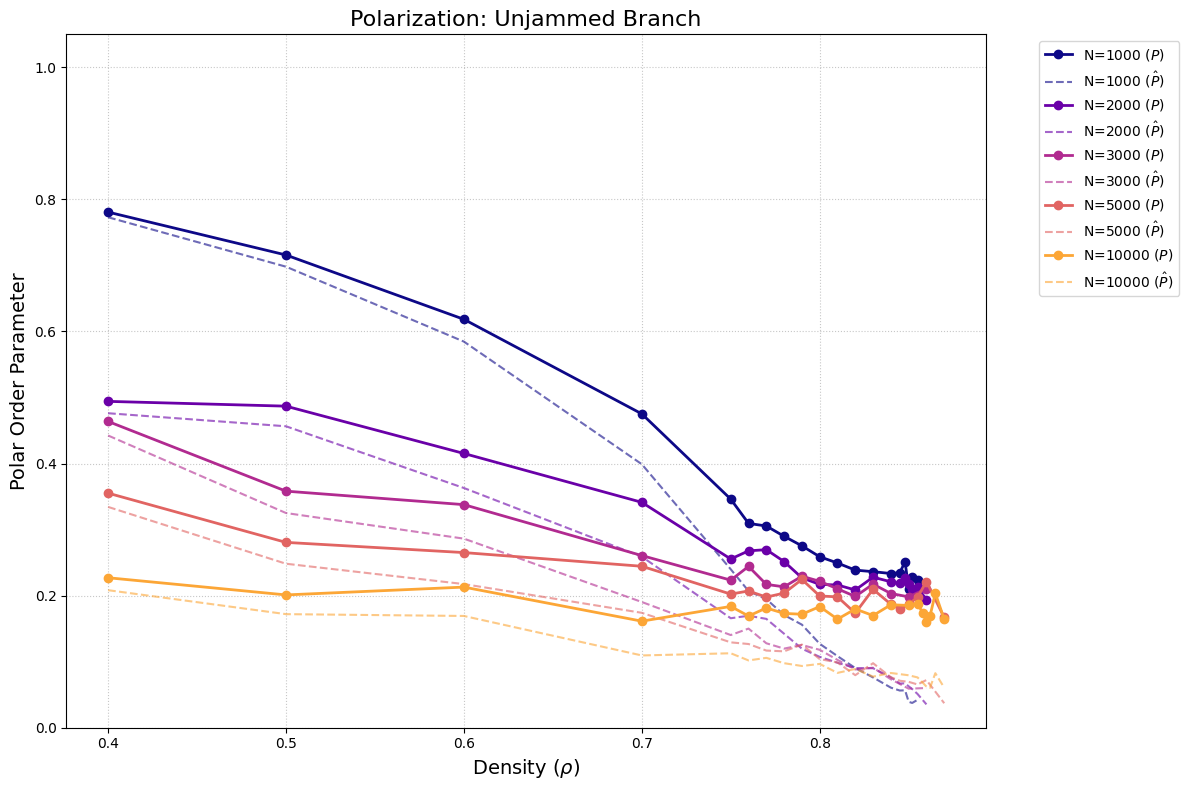

In [12]:
# Style settings
colors = plt.cm.plasma(np.linspace(0, 0.8, len(Ns)))
plt.figure(figsize=(12, 8))
# Plot
for i, N in enumerate(Ns):
    subset = df_unjammed[df_unjammed['N'] == N]
    plt.plot(subset['rho'], subset['polar_elong'], 'o-', color=colors[i], 
             label=f'N={N} ($P$)', linewidth=2)
    plt.plot(subset['rho'], subset['polar_total'], '--', color=colors[i], 
             alpha=0.6, label=rf'N={N} ($\hat{{P}}$)')

plt.xlabel(r"Density ($\rho$)", fontsize=14)
plt.ylabel("Polar Order Parameter", fontsize=14)
plt.title(r"Polarization: Unjammed Branch", fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(0, 1.05)
plt.tight_layout()

path_unjammed = "graphs/jamming/polarization/unjammed_global_polarization.png"
os.makedirs(os.path.dirname(path_unjammed), exist_ok=True)
plt.savefig(path_unjammed, dpi=600)
plt.show()

And then, all the seeds.

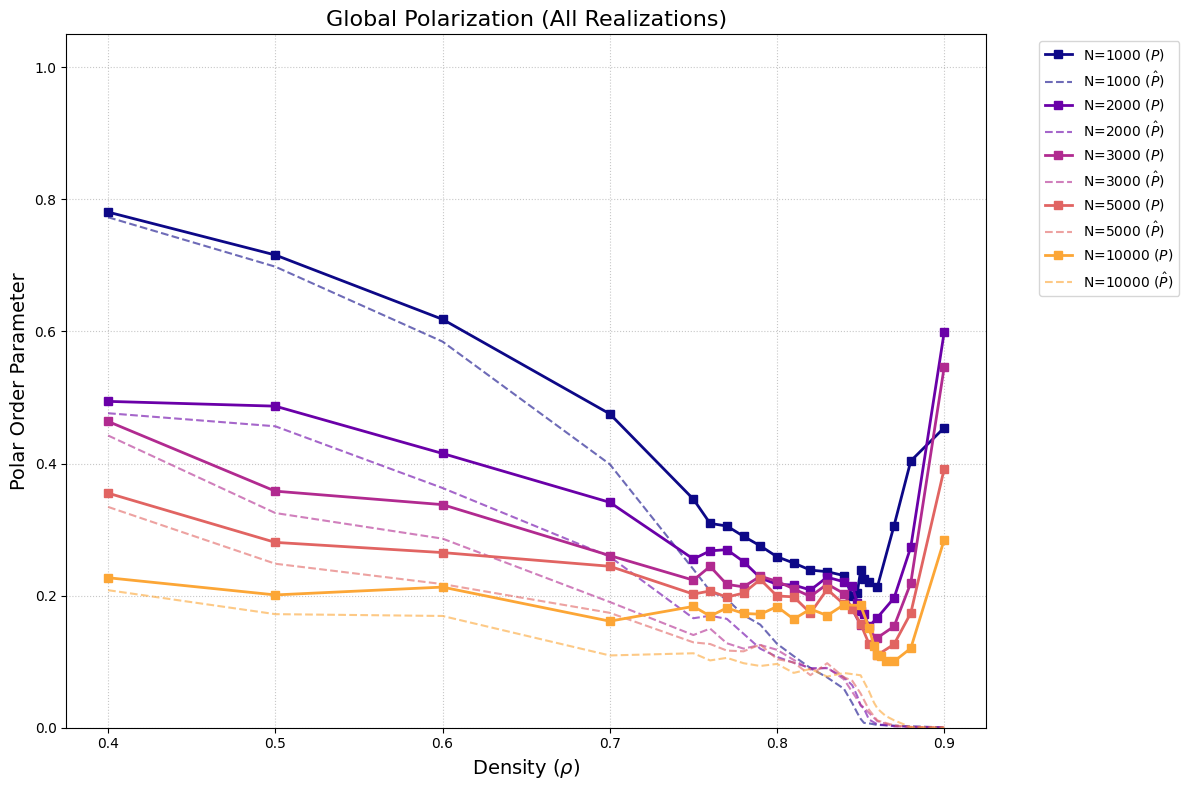

In [13]:
# Style settings
colors = plt.cm.plasma(np.linspace(0, 0.8, len(Ns)))
plt.figure(figsize=(12, 8))
# Plot
for i, N in enumerate(Ns):
    subset = df_total[df_total['N'] == N]
    # Usamos cuadrados 's-' para diferenciar visualmente este gráfico del anterior
    plt.plot(subset['rho'], subset['polar_elong'], 's-', color=colors[i], 
             label=f'N={N} ($P$)', linewidth=2)
    plt.plot(subset['rho'], subset['polar_total'], '--', color=colors[i], 
             alpha=0.6, label=rf'N={N} ($\hat{{P}}$)')

plt.xlabel(r"Density ($\rho$)", fontsize=14)
plt.ylabel("Polar Order Parameter", fontsize=14)
plt.title(r"Global Polarization (All Realizations)", fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(0, 1.05)
plt.tight_layout()

path_total = "graphs/jamming/polarization/total_global_polarization.png"
plt.savefig(path_total, dpi=600)
plt.show()

### Clusters of elongated cells

We start analyzing how are the clusters of elongated cells.

#### Conectivity

Let's see the largest and second largest cluster sizes.

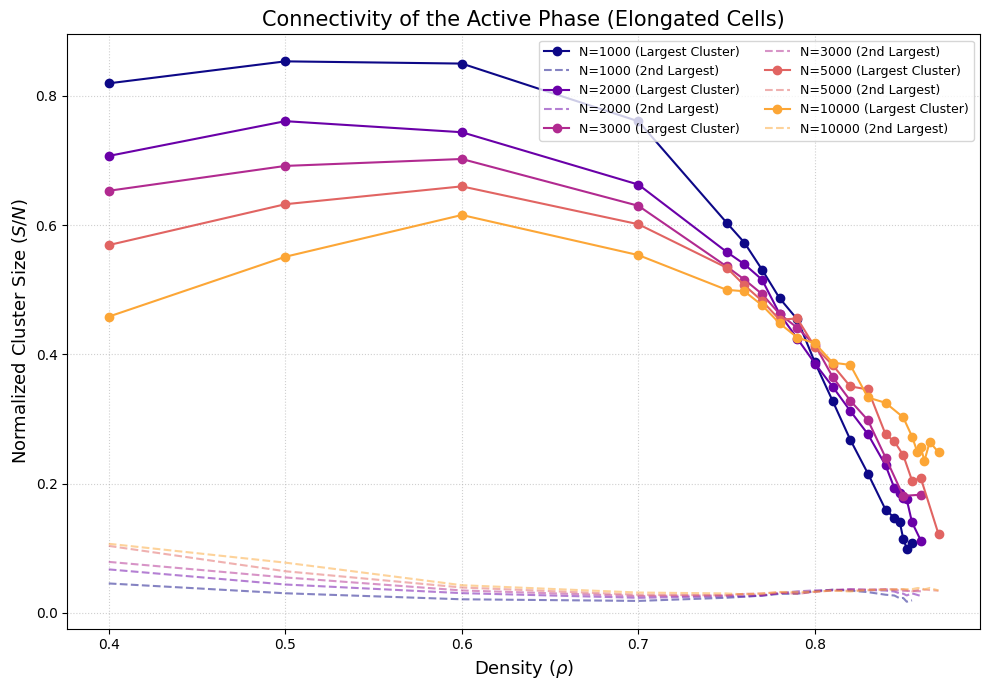

In [11]:
plt.figure(figsize=(10, 7))
colors = plt.cm.plasma(np.linspace(0, 0.8, len(Ns)))

for i, N in enumerate(Ns):
    subset = df_unjammed[df_unjammed['N'] == N]
    
    # Size of largest cluster
    plt.plot(subset['rho'], subset['s_max_elong'], 'o-', color=colors[i], 
             label=f'N={N} (Largest Cluster)')
    
    # Size of second largest cluster
    plt.plot(subset['rho'], subset['s_2max_elong'], '--', color=colors[i], 
             alpha=0.5, label=f'N={N} (2nd Largest)')

plt.xlabel(r"Density ($\rho$)", fontsize=13)
plt.ylabel(r"Normalized Cluster Size ($S/N$)", fontsize=13)
plt.title("Connectivity of the Active Phase (Elongated Cells)", fontsize=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

graph_path = "graphs/jamming/clusters_elongated/elongated_cluster_connectivity.png"
os.makedirs(os.path.dirname(graph_path), exist_ok=True)
plt.savefig(graph_path, dpi=600)
plt.show()

#### Cluster ratio

Let's see the ratio between the 2nd and 1st largest clusters.

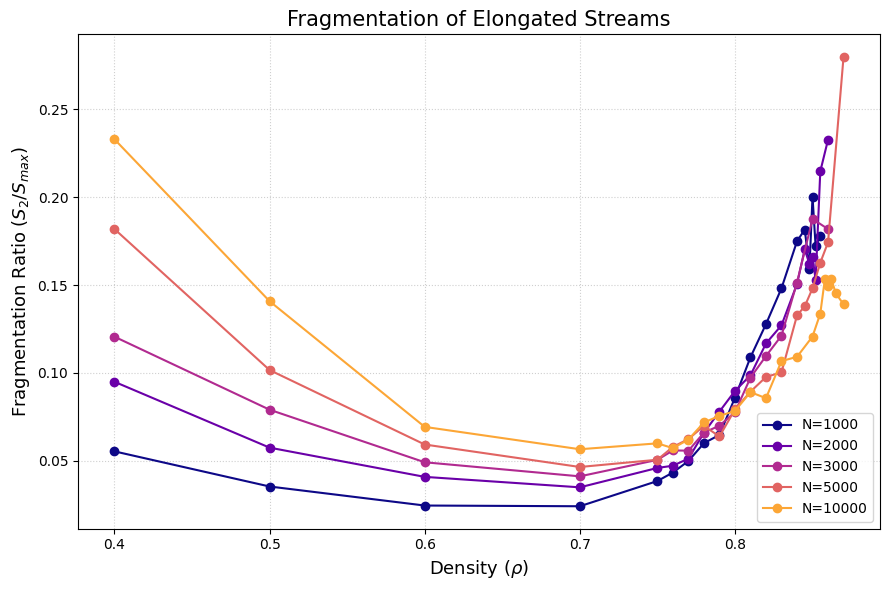

In [12]:
plt.figure(figsize=(9, 6))
for i, N in enumerate(Ns):
    subset = df_unjammed[df_unjammed['N'] == N]
    # Calculate the fragmentation ratio
    fragmentation = subset['s_2max_elong'] / subset['s_max_elong']
    plt.plot(subset['rho'], fragmentation, 'o-', color=colors[i], label=f'N={N}')

plt.xlabel(r"Density ($\rho$)", fontsize=13)
plt.ylabel(r"Fragmentation Ratio ($S_2 / S_{max}$)", fontsize=13)
plt.title("Fragmentation of Elongated Streams", fontsize=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()

graph_path = "graphs/jamming/clusters_elongated/fragmentation.png"
os.makedirs(os.path.dirname(graph_path), exist_ok=True)
plt.savefig(graph_path, dpi=600)
plt.show()

#### Cluster order parameter

Let's see $$\frac{S_1-S_2}{S_1+S_2}$$

First for the unjammed branch:

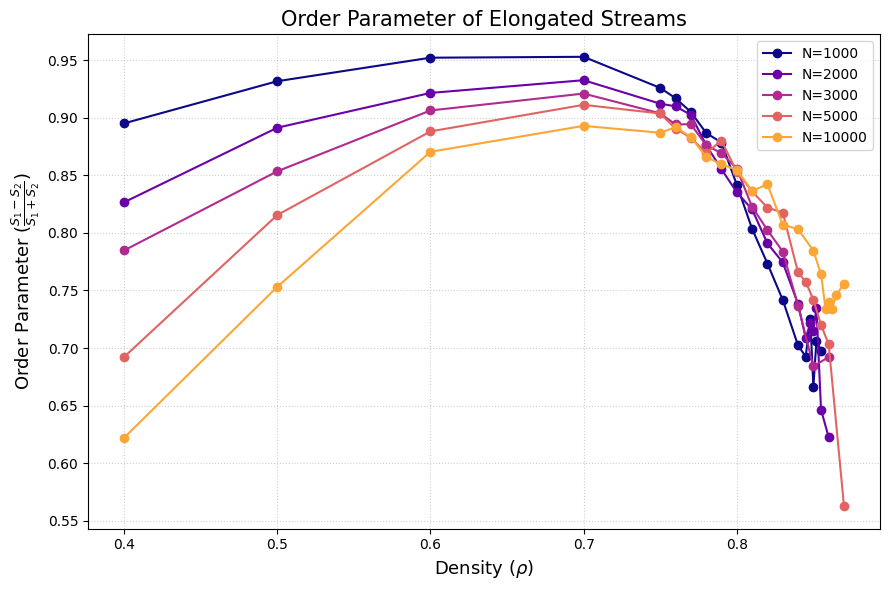

In [19]:
plt.figure(figsize=(9, 6))
for i, N in enumerate(Ns):
    subset = df_unjammed[df_unjammed['N'] == N]
    # Calculate the order parameter
    order_parameter = (subset['s_max_elong'] - subset['s_2max_elong']) / (subset['s_max_elong'] + subset['s_2max_elong'])
    plt.plot(subset['rho'], order_parameter, 'o-', color=colors[i], label=f'N={N}')

plt.xlabel(r"Density ($\rho$)", fontsize=13)
plt.ylabel(r"Order Parameter ($\frac{S_1-S_2}{S_1+S_2}$)", fontsize=13)
plt.title("Order Parameter of Elongated Streams", fontsize=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()

graph_path = "graphs/jamming/clusters_elongated/unjammed_order_parameter.png"
os.makedirs(os.path.dirname(graph_path), exist_ok=True)
plt.savefig(graph_path, dpi=600)
plt.show()

And taking into account every seed:

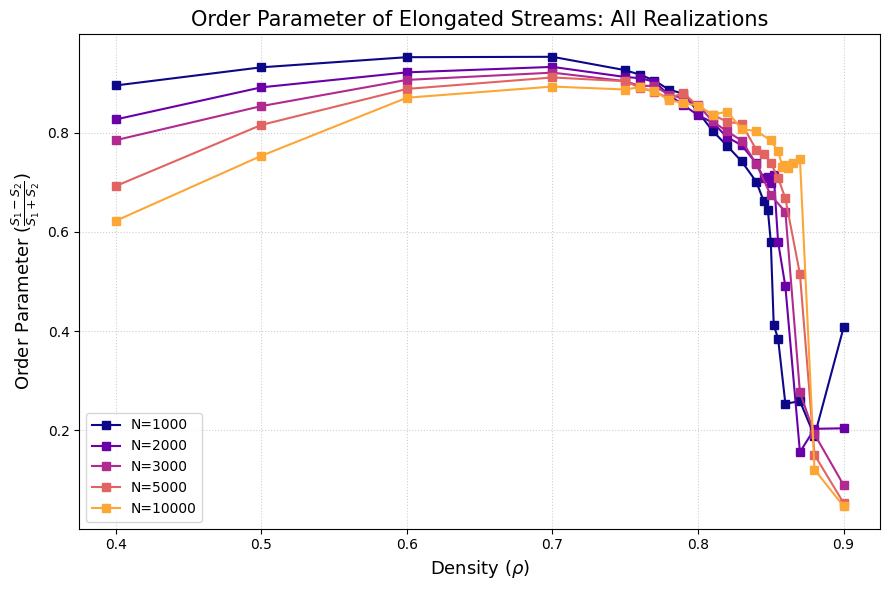

In [17]:
plt.figure(figsize=(9, 6))

for i, N in enumerate(Ns):
    subset = df_total[df_total['N'] == N]
    
    order_parameter = (subset['s_max_elong'] - subset['s_2max_elong']) / \
                      (subset['s_max_elong'] + subset['s_2max_elong'])
    
    plt.plot(subset['rho'], order_parameter, 's-', color=colors[i], label=f'N={N}')

plt.xlabel(r"Density ($\rho$)", fontsize=13)
plt.ylabel(r"Order Parameter ($\frac{S_1-S_2}{S_1+S_2}$)", fontsize=13)
plt.title("Order Parameter of Elongated Streams: All Realizations", fontsize=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()


graph_path_total = "graphs/jamming/clusters_elongated/total_order_parameter.png"
os.makedirs(os.path.dirname(graph_path_total), exist_ok=True)
plt.savefig(graph_path_total, dpi=600)

plt.show()

#### Number of clusters

Now we calculate the number of clusters.

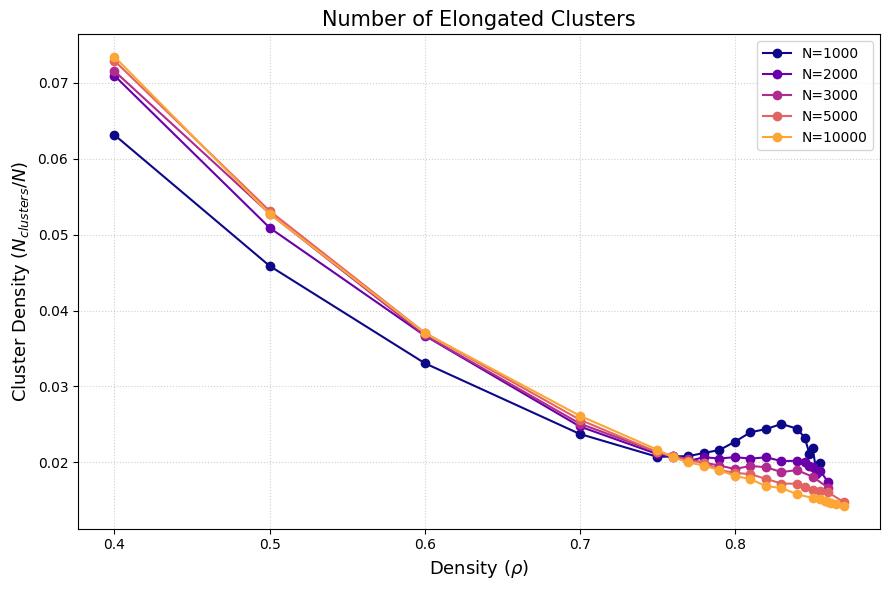

In [14]:
plt.figure(figsize=(9, 6))
colors = plt.cm.plasma(np.linspace(0, 0.8, len(Ns)))

for i, N in enumerate(Ns):
    subset = df_unjammed[df_unjammed['N'] == N]
    
    # Number of elongated clusters
    plt.plot(subset['rho'], subset['n_clusters_elong'] / N, 'o-', 
             color=colors[i], label=f'N={N}')

plt.xlabel(r"Density ($\rho$)", fontsize=13)
plt.ylabel(r"Cluster Density ($N_{clusters} / N$)", fontsize=13)
plt.title("Number of Elongated Clusters", fontsize=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()

graph_path = "graphs/jamming/clusters_elongated/cluster_density_elongated.png"
os.makedirs(os.path.dirname(graph_path), exist_ok=True)
plt.savefig(graph_path, dpi=600)
plt.show()

### Local order

Analyzing Local Order for N=1000...
Analyzing Local Order for N=2000...
Analyzing Local Order for N=3000...
Analyzing Local Order for N=5000...
Analyzing Local Order for N=10000...


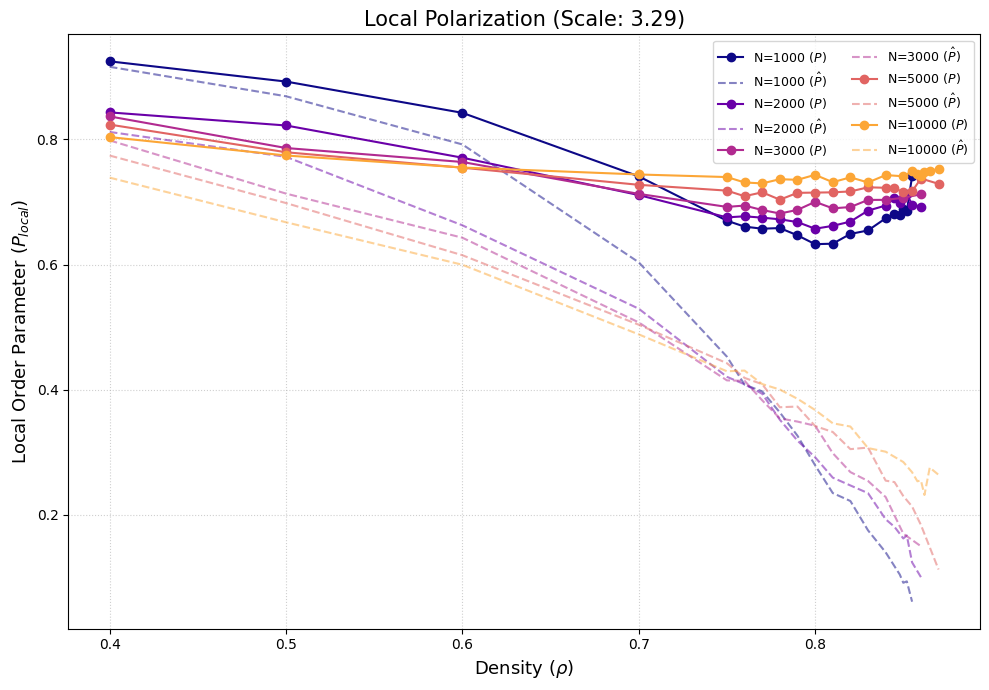

In [21]:
# Settings
df_class = pd.read_csv("data/processed/jamming/final_dataset_classified.csv")
cell_area = np.pi
# Typical size of an elongated cell to define the local neighborhood
grid_cube_size = 2 * np.sqrt(2.7) 

Ns = sorted(df_class['N'].unique())
final_results = []

# Core functions

def load_final_data(dens, seed, num_cells):
    """Loads positions, orientations and aspect ratios for a specific seed."""
    dens_folder = f"{dens:.3f}".replace(".", "_")
    num_cells_folder = f"N={num_cells:_}"
    folder = f"data/{num_cells_folder}/{dens_folder}/dat_final/"
    
    files = [f for f in os.listdir(folder) if f"rng_seed={seed}" in f]
    if not files: return None, None, None
    
    df = pd.read_csv(os.path.join(folder, files[0]))
    pos = df[["position_x", "position_y"]].values
    aspects = df["aspect_ratio"].values
    
    # Build polarization vectors: (cos, sin) for elongated, (0,0) for round
    p_all = np.zeros((len(pos), 2))
    elong_mask = ~np.isclose(aspects, 1)
    p_all[elong_mask, 0] = np.cos(df["orientation"].values[elong_mask])
    p_all[elong_mask, 1] = np.sin(df["orientation"].values[elong_mask])
    
    return pos, p_all, aspects

def calculate_dual_local_order(num_cells, dens, seeds):
    """Calculates both Total and Active-Only local order parameters."""
    res_total = []
    res_active = []
    
    for seed in seeds:
        pos, p_all, aspects = load_final_data(dens, seed, num_cells)
        if pos is None: continue
        
        # Grid construction (Cell Lists)
        bounds = np.sqrt(num_cells * cell_area / dens)
        n_buckets = int(np.floor(bounds / grid_cube_size))
        cube_size = bounds / n_buckets
        
        grid = {}
        for i, p in enumerate(pos):
            key = tuple(np.floor(p / cube_size).astype(int) % n_buckets)
            grid.setdefault(key, []).append(i)
            
        offsets = [(dx, dy) for dx in [-1,0,1] for dy in [-1,0,1]]
        is_elongated = ~np.isclose(aspects, 1)
        
        mags_total = []
        mags_active = []
        
        for i in range(len(pos)):
            key = tuple(np.floor(pos[i] / cube_size).astype(int) % n_buckets)
            neighbors_idx = []
            for dx, dy in offsets:
                nk = ((key[0]+dx) % n_buckets, (key[1]+dy) % n_buckets)
                if nk in grid: neighbors_idx.extend(grid[nk])
            
            if not neighbors_idx: continue
            
            p_sum = np.sum(p_all[neighbors_idx], axis=0)
            
            # 1. Total Local Order (Divided by all cells in box)
            mags_total.append(np.linalg.norm(p_sum / len(neighbors_idx)))
            
            # 2. Active Local Order (Divided only by elongated cells in box)
            n_elong = np.sum(is_elongated[neighbors_idx])
            if n_elong > 0:
                mags_active.append(np.linalg.norm(p_sum / n_elong))
            # If no elongated cells, it doesn't contribute to the active average
        
        res_total.append(np.mean(mags_total))
        if mags_active: res_active.append(np.mean(mags_active))
        
    return np.mean(res_total), np.mean(res_active)

# MAIN LOOP (Unjammed Branch only)

for N in Ns:
    densities = sorted(df_class[df_class['N'] == N]['rho'].unique())
    print(f"Analyzing Local Order for N={N}...")
    
    for rho in densities:
        # Filter only flowing realizations
        seeds_uj = df_class[(df_class['N'] == N) & 
                            (df_class['rho'] == rho) & 
                            (df_class['status'] == 'unjammed')]['seed'].unique()
        
        if len(seeds_uj) == 0: continue
        
        p_tot, p_act = calculate_dual_local_order(N, rho, seeds_uj)
        final_results.append({
            'N': N, 'rho': rho, 
            'P_local_total': p_tot, 
            'P_local_active': p_act
        })

df_local = pd.DataFrame(final_results)

# Plots
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
colors = plt.cm.plasma(np.linspace(0, 0.8, len(Ns)))

for i, N in enumerate(Ns):
    sub = df_local[df_local['N'] == N]
    # Solid line: Active-only (The "pure" order of oncostreams)
    ax.plot(sub['rho'], sub['P_local_active'], 'o-', color=colors[i], 
            label=f'N={N} ($P$)')
    # Dashed line: Total (Diluted by round cells)
    ax.plot(sub['rho'], sub['P_local_total'], '--', color=colors[i], 
            alpha=0.5, label=rf'N={N} ($\hat{{P}}$)')

ax.set_xlabel(r"Density ($\rho$)", fontsize=13)
ax.set_ylabel(r"Local Order Parameter ($P_{local}$)", fontsize=13)
ax.set_title(f"Local Polarization (Scale: {grid_cube_size:.2f})", fontsize=15)
ax.legend(ncol=2, fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("graphs/jamming/polarization/unjammed_local_order.png", dpi=600)
plt.show()

And finally, with all the seeds:

Analyzing Global Local Order for N=1000...
Analyzing Global Local Order for N=2000...
Analyzing Global Local Order for N=3000...
Analyzing Global Local Order for N=5000...
Analyzing Global Local Order for N=10000...


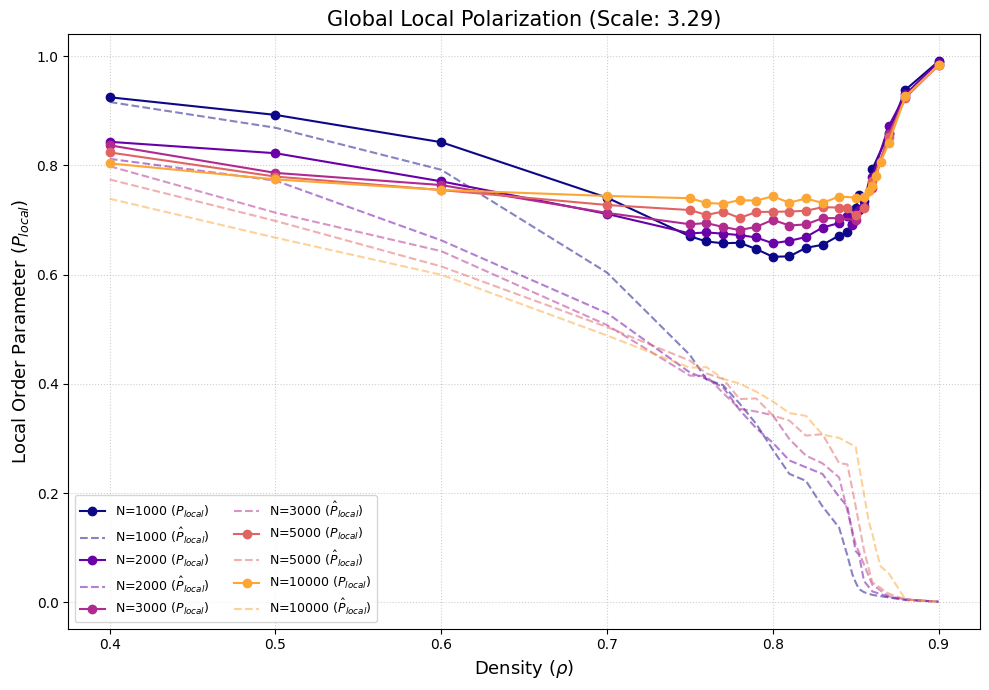

In [23]:
# Settings
df_class = pd.read_csv("data/processed/jamming/final_dataset_classified.csv")
cell_area = np.pi
# Typical size of an elongated cell to define the local neighborhood
grid_cube_size = 2 * np.sqrt(2.7) 

Ns = sorted(df_class['N'].unique())
total_final_results = []

# Core functions

def load_final_data(dens, seed, num_cells):
    """Loads positions, orientations and aspect ratios for a specific seed."""
    dens_folder = f"{dens:.3f}".replace(".", "_")
    num_cells_folder = f"N={num_cells:_}"
    folder = f"data/{num_cells_folder}/{dens_folder}/dat_final/"
    
    files = [f for f in os.listdir(folder) if f"rng_seed={seed}" in f]
    if not files: return None, None, None
    
    df = pd.read_csv(os.path.join(folder, files[0]))
    pos = df[["position_x", "position_y"]].values
    aspects = df["aspect_ratio"].values
    
    # Build polarization vectors: (cos, sin) for elongated, (0,0) for round
    p_all = np.zeros((len(pos), 2))
    elong_mask = ~np.isclose(aspects, 1)
    p_all[elong_mask, 0] = np.cos(df["orientation"].values[elong_mask])
    p_all[elong_mask, 1] = np.sin(df["orientation"].values[elong_mask])
    
    return pos, p_all, aspects

def calculate_dual_local_order(num_cells, dens, seeds):
    """Calculates both Total and Active-Only local order parameters."""
    res_total = []
    res_active = []
    
    for seed in seeds:
        pos, p_all, aspects = load_final_data(dens, seed, num_cells)
        if pos is None: continue
        
        # Grid construction (Cell Lists)
        bounds = np.sqrt(num_cells * cell_area / dens)
        n_buckets = int(np.floor(bounds / grid_cube_size))
        cube_size = bounds / n_buckets
        
        grid = {}
        for i, p in enumerate(pos):
            key = tuple(np.floor(p / cube_size).astype(int) % n_buckets)
            grid.setdefault(key, []).append(i)
            
        offsets = [(dx, dy) for dx in [-1,0,1] for dy in [-1,0,1]]
        is_elongated = ~np.isclose(aspects, 1)
        
        mags_total = []
        mags_active = []
        
        for i in range(len(pos)):
            key = tuple(np.floor(pos[i] / cube_size).astype(int) % n_buckets)
            neighbors_idx = []
            for dx, dy in offsets:
                nk = ((key[0]+dx) % n_buckets, (key[1]+dy) % n_buckets)
                if nk in grid: neighbors_idx.extend(grid[nk])
            
            if not neighbors_idx: continue
            
            p_sum = np.sum(p_all[neighbors_idx], axis=0)
            
            # 1. Total Local Order (Divided by all cells in box)
            mags_total.append(np.linalg.norm(p_sum / len(neighbors_idx)))
            
            # 2. Active Local Order (Divided only by elongated cells in box)
            n_elong = np.sum(is_elongated[neighbors_idx])
            if n_elong > 0:
                mags_active.append(np.linalg.norm(p_sum / n_elong))
        
        res_total.append(np.mean(mags_total))
        if mags_active: res_active.append(np.mean(mags_active))
        
    return np.mean(res_total), np.mean(res_active)

# MAIN LOOP (All Realizations)

for N in Ns:
    densities = sorted(df_class[df_class['N'] == N]['rho'].unique())
    print(f"Analyzing Global Local Order for N={N}...")
    
    for rho in densities:
        # Filter all realizations for this N and rho (regardless of status)
        seeds_all = df_class[(df_class['N'] == N) & 
                             (df_class['rho'] == rho)]['seed'].unique()
        
        if len(seeds_all) == 0: continue
        
        p_tot, p_act = calculate_dual_local_order(N, rho, seeds_all)
        total_final_results.append({
            'N': N, 'rho': rho, 
            'P_local_total': p_tot, 
            'P_local_active': p_act
        })

df_local_total = pd.DataFrame(total_final_results)

# Plots
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
colors = plt.cm.plasma(np.linspace(0, 0.8, len(Ns)))

for i, N in enumerate(Ns):
    sub = df_local_total[df_local_total['N'] == N]
    # Solid line: Active-only (The "pure" order of oncostreams)
    ax.plot(sub['rho'], sub['P_local_active'], 'o-', color=colors[i], 
            label=f'N={N} ($P_{{local}}$)')
    # Dashed line: Total (Diluted by round cells)
    ax.plot(sub['rho'], sub['P_local_total'], '--', color=colors[i], 
            alpha=0.5, label=rf'N={N} ($\hat{{P}}_{{local}}$)')

ax.set_xlabel(r"Density ($\rho$)", fontsize=13)
ax.set_ylabel(r"Local Order Parameter ($P_{local}$)", fontsize=13)
ax.set_title(f"Global Local Polarization (Scale: {grid_cube_size:.2f})", fontsize=15)
ax.legend(ncol=2, fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
graph_path = "graphs/jamming/polarization/total_local_order.png"
os.makedirs(os.path.dirname(graph_path), exist_ok=True)
plt.savefig(graph_path, dpi=600)
plt.show()